## HW 4: Policy gradient
_Reference: based on Practical RL course by YSDA_

In this notebook you have to master Policy gradient Q-learning and apply it to familiar (and not so familiar) RL problems once again.

To get used to `gymnasium` package, please, refer to the [documentation](https://gymnasium.farama.org/introduction/basic_usage/).


In the end of the notebook, please, copy the functions you have implemented to the template file and submit it to the Contest.

In [43]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

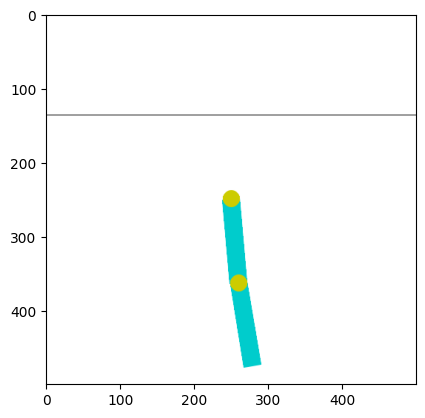

In [44]:
env = gym.make("Acrobot-v1", render_mode="rgb_array")

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape

plt.imshow(env.render())

In [45]:
import torch
import torch.nn as nn

In [56]:
class Actor(nn.Module):
  def __init__(self):
    super(Actor,self).__init__()
    self.l1=nn.Linear(6,40)
    self.l2=nn.Linear(40,3)
    self.log=nn.Sigmoid()
    self.sm=nn.Softmax()
  def forward(self,x):
    out=self.l1(x)
    out=self.log(out)
    out=self.l2(out)
    return out

In [61]:
class Critic(nn.Module):
  def __init__(self):
    super(Critic,self).__init__()
    self.l1=nn.Linear(7,40)
    self.l2=nn.Linear(40,1)
    self.log=nn.Sigmoid()
    self.relu=nn.ReLU()
  def forward(self,x):
    out=self.l1(x)
    out=self.relu(out)
    out=self.l2(out)
    out=self.relu(out)
    return out

In [62]:
actor=Actor()
critic=Critic()

In [48]:
def predict_probs(states, model):
    probs = torch.softmax(model(torch.from_numpy(states).type(torch.FloatTensor)),dim=-1)

    return probs.detach().numpy()

In [49]:
def predict_values(states, model):
  values =
  return

In [50]:
def generate_session(env, t_max=500):
    states, actions, rewards = [], [], []
    s, info = env.reset()

    for t in range(t_max):
        action_probs = predict_probs(np.array([s]),model)[0]
        a = np.random.choice(n_actions, p=action_probs)
        new_s, r, done, truncated, info = env.step(a)
        states.append(s)
        actions.append(a)
        rewards.append(r)

        s = new_s
        if done:
            break

    return states, actions, rewards

In [51]:
def get_cumulative_rewards(rewards,  # rewards at each step
                           gamma=0.99  # discount for reward
                           n=40):
    cumulative_rewards = np.zeros(len(rewards))
    G_t=0
    for i in range(len(rewards)):
      G_t=rewards[len(rewards)-i-1]+gamma*G_t
      cumulative_rewards[len(rewards)-i-1]=G_t

    return cumulative_rewards

### Loss function and updates

We now need to define objective and update over policy gradient.

Our objective function is

$$ J \approx  { 1 \over N } \sum_{s_i,a_i} G(s_i,a_i) $$

REINFORCE defines a way to compute the gradient of the expected reward with respect to policy parameters. The formula is as follows:

$$ \nabla_\theta \hat J(\theta) \approx { 1 \over N } \sum_{s_i, a_i} \nabla_\theta \log \pi_\theta (a_i \mid s_i) \cdot G_t(s_i, a_i) $$

We can abuse PyTorch's capabilities for automatic differentiation by defining our objective function as follows:

$$ \hat J(\theta) \approx { 1 \over N } \sum_{s_i, a_i} \log \pi_\theta (a_i \mid s_i) \cdot G_t(s_i, a_i) $$

When you compute the gradient of that function with respect to network weights $\theta$, it will become exactly the policy gradient.

Final loss should also include the entropy regularization term $H(\pi_\theta (a_i \mid s_i))$ to enforce the exploration:

$$
L = -\hat J(\theta) - \lambda H(\pi_\theta (a_i \mid s_i)),
$$
where $\lambda$ is the `entropy_coef`.

In [52]:
def to_one_hot(y_tensor, ndims):
    y_tensor = y_tensor.type(torch.LongTensor).view(-1, 1)
    y_one_hot = torch.zeros(
        y_tensor.size()[0], ndims).scatter_(1, y_tensor, 1)
    return y_one_hot

In [53]:
n_actions = 3;
def get_loss(logits, actions, rewards, n_actions=n_actions, gamma=0.99, entropy_coef=1e-2):
    actions = torch.tensor(actions, dtype=torch.int32)
    cumulative_returns = np.array(get_cumulative_rewards(rewards, gamma))
    cumulative_returns = torch.tensor(cumulative_returns, dtype=torch.float32)

    probs = torch.softmax(logits,dim=-1)

    log_probs = torch.log_softmax(logits,dim=-1)
    log_probs_for_actions = torch.sum(log_probs*to_one_hot(actions,n_actions),dim=1) # [batch,]
    J_hat = torch.mean(log_probs_for_actions*cumulative_returns)  # a number

    entropy = -1*torch.sum(probs*log_probs,dim=1).mean()
    loss = -J_hat-entropy_coef*entropy

    return loss

In [54]:
optimizer = torch.optim.Adam(model.parameters(), 1e-3)

def train_on_session(states, actions, rewards, gamma=0.99, entropy_coef=1e-2):
    states = torch.tensor(states, dtype=torch.float32)
    logits = model(states)
    # cast everything into torch tensors
    loss = get_loss(logits, actions, rewards, n_actions=n_actions, gamma=gamma, entropy_coef=entropy_coef)
    # Gradient descent step
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    # technical: return session rewards to print them later
    return np.sum(rewards)

## Bonus part (no points, just for the interested ones)

Try solving the `Acrobot-v1` environment. It is more complex than regular `CartPole-v1`, so the default Policy Gradient (REINFORCE) algorithm might not work. Maybe the baseline idea could help...

![Acrobot](https://gymnasium.farama.org/_images/acrobot.gif)


In [33]:
model=Model()

In [35]:
for i in range(500):
    rewards = [train_on_session(*generate_session(env), entropy_coef=1e-3) for _ in range(100)]  # generate new sessions

    print("mean reward:%.3f" % (np.mean(rewards)))

    if np.mean(rewards) > -100:
        print("You Win!")  # but you can train even further
        break

mean reward:-610.207
mean reward:-638.496
mean reward:-591.838
mean reward:-620.708
mean reward:-590.113
mean reward:-613.908
mean reward:-587.630
mean reward:-601.839
mean reward:-609.491
mean reward:-627.809
mean reward:-594.701
mean reward:-625.247
mean reward:-619.630
mean reward:-623.854
mean reward:-570.856
mean reward:-586.255
mean reward:-617.367
mean reward:-599.428
mean reward:-623.210
mean reward:-615.650
mean reward:-603.854
mean reward:-597.446
mean reward:-588.001
mean reward:-645.434
mean reward:-588.132
mean reward:-612.818
mean reward:-620.430
mean reward:-622.522
mean reward:-631.335


KeyboardInterrupt: 